In [1]:
import sys, os
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from pathlib import Path
import glob

In [ ]:
def process_file(filename):
    try:
        with open(filename, "r") as f:
            lines = f.readlines()[4:-1]

        theta_data, phior_data = [], []
        for line in lines:
            values = line.split()
            if len(values) >= 13:
                try:
                    t = float(values[8])
                    p = float(values[9])
                    if np.isnan(t) or np.isnan(p):
                        continue
                    theta_data.append(t)
                    phior_data.append(p)
                except ValueError:
                    continue

        if not theta_data:
            print(f"⚠ Cap dada vàlida a {filename}, saltant...")
            return

        theta_data = np.array(theta_data)
        phior_data = np.array(phior_data)

        fig, ax = plt.subplots(figsize=(6, 5))
        h = ax.hist2d(theta_data, phior_data, bins=100, cmap='Blues', alpha=0.75)
        ax.set_title("Histograma 2D")
        ax.set_xlabel(r'$\cos(\theta)$')
        ax.set_ylabel(r'$\phi$ (graus)')
        ax.set_xlim(-1, 1)
        ax.set_ylim(-180, 180)
        fig.colorbar(h[3], ax=ax, label='Densitat')
        plt.tight_layout()
        plt.show()

    except FileNotFoundError:
        print(f"⚠ Fitxer {filename} no trobat, saltant...")

filenames = sorted(glob.glob("/home/aressanuy/Desktop/doc/pentaeritritol/P0/angula/ang_400_*.dat"))
#filenames = sorted(glob.glob("/home/aressanuy/Desktop/doc/pentaeritritol/angula/ang_480_*.dat"))
if not filenames:
    print("⚠ Cap fitxer trobat amb aquest patró")
else:
    for filename in filenames:
        print(f"Processant {filename}...")
        process_file(filename)




Processant 16 fitxers...


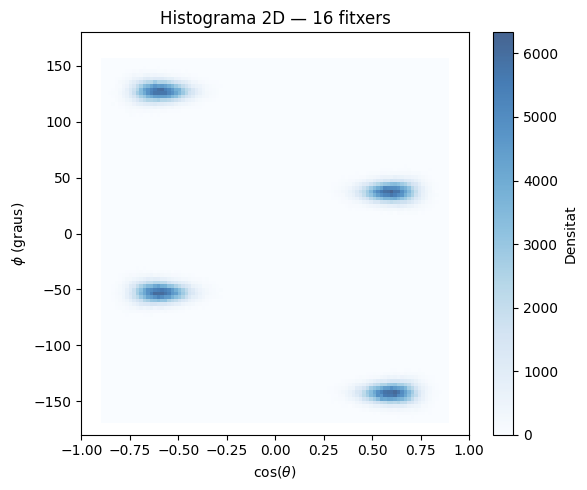

In [16]:
def process_files_combined(filenames):
    theta_all, phi_all = [], []

    for filename in filenames:
        try:
            with open(filename, "r") as f:
                lines = f.readlines()[4:-1]

            for line in lines:
                values = line.split()
                if len(values) >= 13:
                    try:
                        t = float(values[8])
                        p = float(values[9])
                        if np.isnan(t) or np.isnan(p):
                            continue
                        theta_all.append(t)
                        phi_all.append(p)
                    except ValueError:
                        continue

        except FileNotFoundError:
            print(f"⚠ Fitxer {filename} no trobat, saltant...")

    if not theta_all:
        print("⚠ Cap dada vàlida, saltant...")
        return

    theta_all = np.array(theta_all)
    phi_all   = np.array(phi_all)

    fig, ax = plt.subplots(figsize=(6, 5))
    h = ax.hist2d(theta_all, phi_all, bins=100, cmap='Blues', alpha=0.75)
    ax.set_title(f"Histograma 2D — {len(filenames)} fitxers")
    ax.set_xlabel(r'$\cos(\theta)$')
    ax.set_ylabel(r'$\phi$ (graus)')
    ax.set_xlim(-1, 1)
    ax.set_ylim(-180, 180)
    fig.colorbar(h[3], ax=ax, label='Densitat')
    plt.tight_layout()
    plt.show()


filenames = sorted(glob.glob("/home/aressanuy/Desktop/doc/pentaeritritol/P0/angula/ang_400_*.dat"))
#filenames = sorted(glob.glob("/home/aressanuy/Desktop/doc/pentaeritritol/angula/ang_480_*.dat"))

if not filenames:
    print("⚠ Cap fitxer trobat amb aquest patró")
else:
    print(f"Processant {len(filenames)} fitxers...")
    process_files_combined(filenames)